# Algorithmic trading on the German electricity market

Data challenge proposed by **Engelhart** during the Ensimag technology conference (22/09/2026)

**Goal:** for each 15-minute period, predict the **spread** = imbalance price − day-ahead price in Germany, from the day-ahead forecasts of wind, solar and load.

**Trading rule (fixed by the challenge):**
- forecast ≥ 0 -> buy 50 MW on the day-ahead market (long)
- forecast < 0 -> sell 50 MW on the day-ahead market (short)
- no position when abs(imbalance price) > 1000 € (too risky)

The score is the cumulated PnL (€) over the test period (January to September 2024).

### Importing the necessary libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import TimeSeriesSplit

### Loading the data

In [2]:
train = pd.read_csv("train.csv", parse_dates=["date"], index_col=0)
test = pd.read_csv("test.csv", parse_dates=["date"])
imbalances = pd.read_csv("imbalances.csv", parse_dates=["date"], index_col=0)["imbalances"]

x_train = train[["wind", "solar", "load"]]
y_train = train["spread"]
x_test = test.set_index("date")[["wind", "solar", "load"]]

print(f"Train: {train.index.min()} -> {train.index.max()} ({len(train)} periods)")
print(f"Test:  {x_test.index.min()} -> {x_test.index.max()} ({len(x_test)} periods)")

Train: 2020-01-01 00:00:00 -> 2023-12-31 23:45:00 (140157 periods)
Test:  2024-01-01 00:15:00 -> 2024-09-08 10:45:00 (24138 periods)


## 1. Data exploration

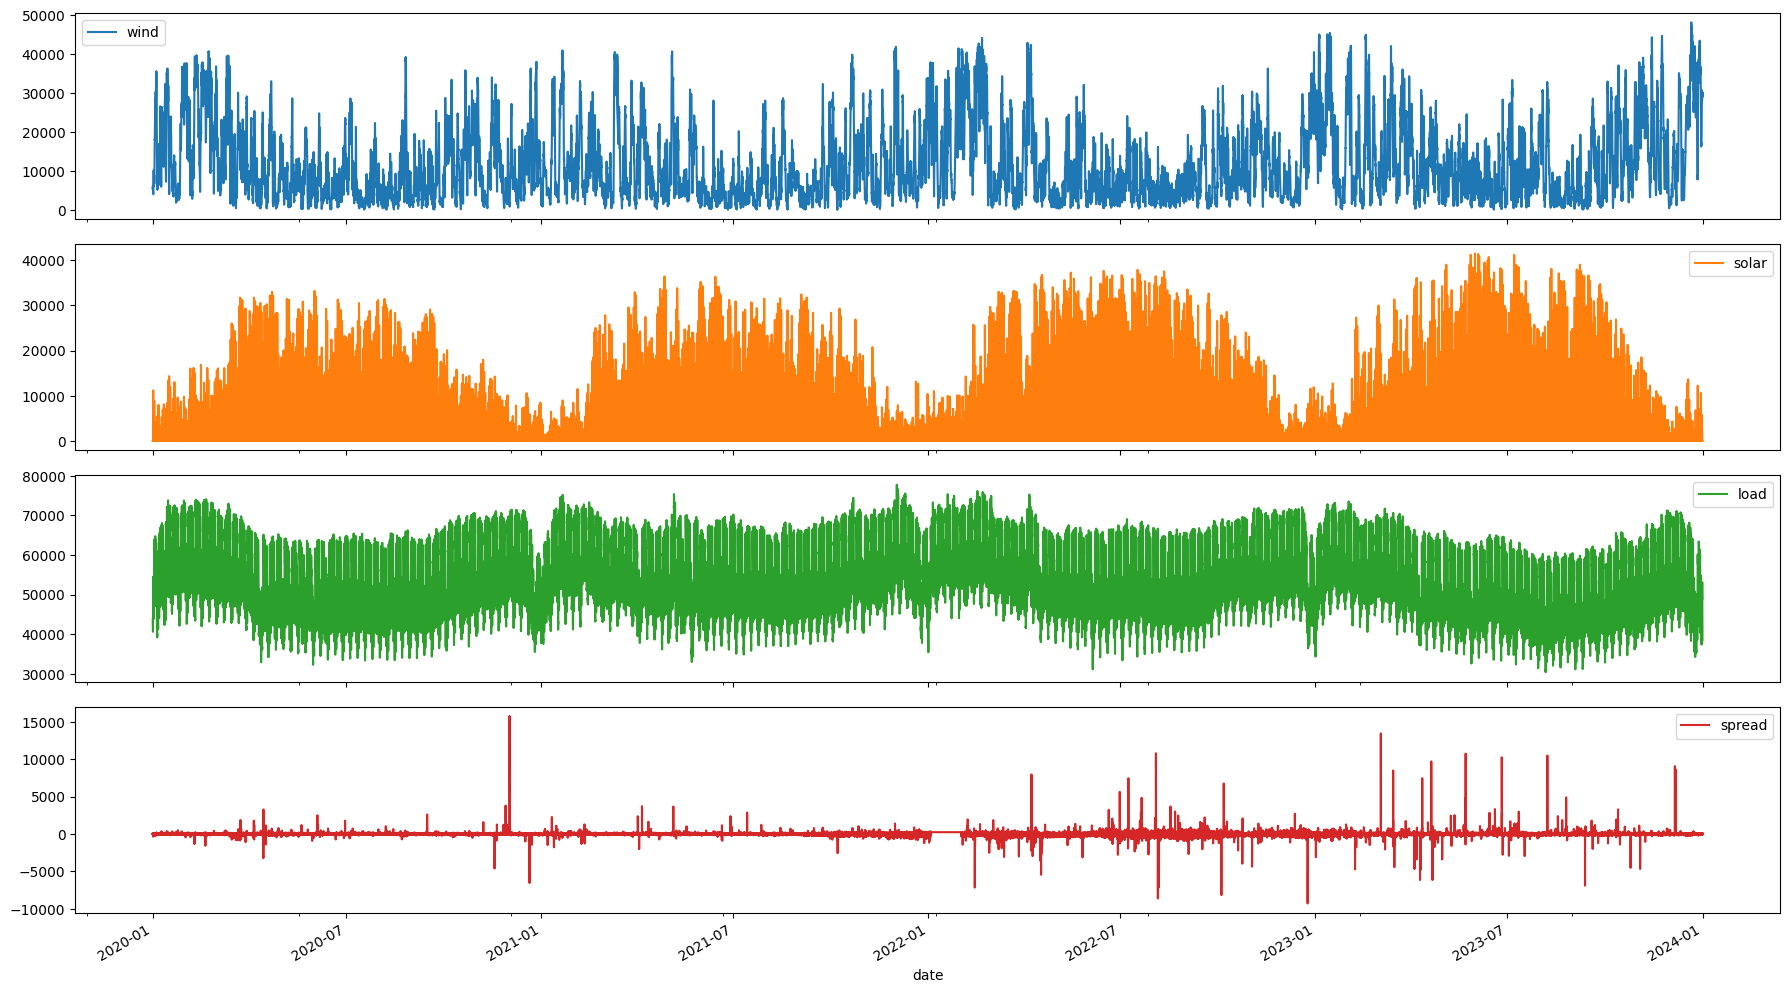

In [3]:
train[["wind", "solar", "load", "spread"]].plot(subplots=True, figsize=(18, 10), sharex=True)
plt.tight_layout()
plt.show()

### Corrupt data: constant spread in January 2022

From 2022-01-03 to 2022-02-01, the spread is stuck at exactly 250 € for about a month, while the imbalance price keeps moving normally. The spread is the difference between two prices, so it cannot be constant over a month: the day-ahead price was most likely missing and replaced by a fixed value.

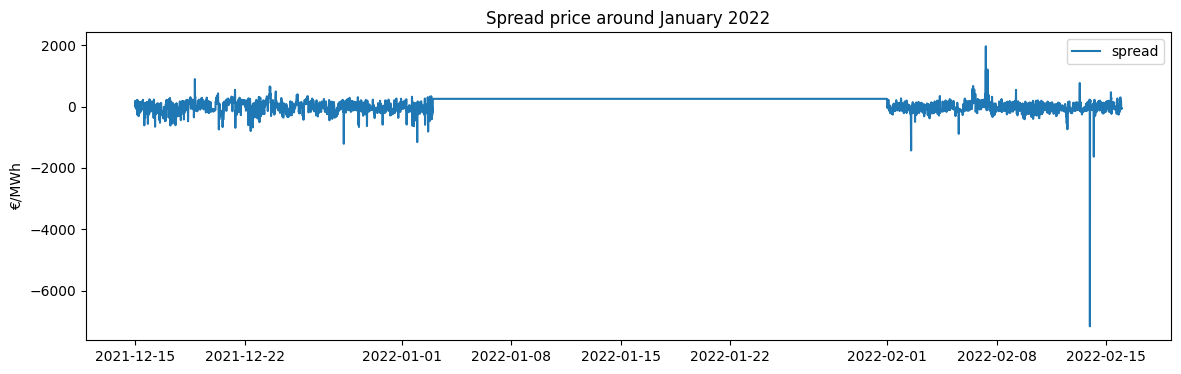

Corrupt periods: 2785 (2022-01-03 00:00:00 -> 2022-02-01 00:00:00)


In [4]:
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(train.loc["2021-12-15":"2022-02-15", "spread"], label="spread")
ax.set_title("Spread price around January 2022")
ax.set_ylabel("€/MWh")
ax.legend()
plt.show()

# periods where the spread is stuck at 250 € in January 2022
corrupt = (train.index >= "2022-01-03") & (train.index <= "2022-02-01") & (train["spread"].values == 250)
print(f"Corrupt periods: {corrupt.sum()} ({train.index[corrupt].min()} -> {train.index[corrupt].max()})")

**What to do with these periods:**
- **Remove them from training:** a constant value of 250 € has nothing to do with wind, solar or load, so the model would learn a wrong relationship.
- **Remove them from the evaluation:** a PnL computed on a fake spread means nothing. For instance, always long would earn about 35 M€ on this month alone, only because the fake spread is positive.

## 2. Model: Linear regression with lags and calendar variables

**Lags:** the spread also depends on how wind, solar and load forecasts evolve and not only the current values (the grid is often out of balance when production or consumption changes quickly). For each variable, we add its value 15, 30, 45 and 60 minutes before. These forecasts are all known the day before, so they can be used when trading.

**Calendar variables:** the spread has a strong daily profile (positive at night, negative during the evening). Hour, weekday and month are encoded as categories (dummy variables) because with `hour` = 0 to 23 as a number, a linear model would assume that the effect of 23:00 is 23 times the effect of 1:00.

In [5]:
df = pd.concat([x_train, x_test])

df["wind_lag_1"] = df["wind"].shift(1)
df["wind_lag_2"] = df["wind"].shift(2)
df["wind_lag_3"] = df["wind"].shift(3)
df["wind_lag_4"] = df["wind"].shift(4)

df["solar_lag_1"] = df["solar"].shift(1)
df["solar_lag_2"] = df["solar"].shift(2)
df["solar_lag_3"] = df["solar"].shift(3)
df["solar_lag_4"] = df["solar"].shift(4)

df["load_lag_1"] = df["load"].shift(1)
df["load_lag_2"] = df["load"].shift(2)
df["load_lag_3"] = df["load"].shift(3)
df["load_lag_4"] = df["load"].shift(4)

df["hour"] = df.index.hour
df["weekday"] = df.index.dayofweek
df["month"] = df.index.month

df = df.bfill()

# dummy vars for date
df = pd.get_dummies(df, columns=["hour", "weekday", "month"], dtype=float)

# Split back
features_train = df.loc[x_train.index]
features_test = df.loc[x_test.index]

print(features_train.shape)
features_train.head()

(140157, 58)


,wind,solar,load,wind_lag_1,wind_lag_2,wind_lag_3,wind_lag_4,solar_lag_1,solar_lag_2,solar_lag_3,...,month_3,month_4,month_5,month_6,month_7,month_8,month_9,month_10,month_11,month_12
date,,,,,,,,,,,,,,,,,,,,,
2020-01-01 00:00:00,6084.0,0.0,43915.0,6084.0,6084.0,6084.0,6084.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2020-01-01 00:15:00,5739.0,0.0,43770.0,6084.0,6084.0,6084.0,6084.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2020-01-01 00:30:00,5774.0,0.0,43267.0,5739.0,6084.0,6084.0,6084.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2020-01-01 00:45:00,5804.0,0.0,42934.0,5774.0,5739.0,6084.0,6084.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2020-01-01 01:00:00,5791.0,0.0,42718.0,5804.0,5774.0,5739.0,6084.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## 3. Evaluation setup

**Cross-validation:** the data is a time series; `TimeSeriesSplit` trains on the past and validates on the following block. The model and the benchmarks are evaluated on exactly the same periods, without the corrupt ones, so their PnL can be compared.

**PnL:** same function as the challenge metric.

**Benchmarks**, to give a scale to the results:
- *always long*: buy 50 MW every period, no model
- *perfect foresight*: knowing the true sign of the spread, i.e. the maximum achievable PnL

In [6]:
def calculate_pnl(forecast, spread, imbalance_price, pos_mw=50):
    """PnL per period (€): long if forecast >= 0, short otherwise, no position if abs(imbalance price) > 1000 €."""
    position = np.where(forecast >= 0, pos_mw, -pos_mw)
    return np.where(np.abs(imbalance_price) > 1000, 0, position * spread)


tscv = TimeSeriesSplit(n_splits=5)
folds = list(tscv.split(x_train))

# periods evaluated by the cross-validation, without the corrupt ones
val_index = np.concatenate([val_idx for _, val_idx in folds])
val_index = val_index[~corrupt[val_index]]

spread_val = y_train.iloc[val_index]
imbalances_val = imbalances.iloc[val_index].values

# benchmarks
pnl_always_long = calculate_pnl(np.ones(len(val_index)), spread_val.values, imbalances_val)
pnl_perfect = calculate_pnl(spread_val.values, spread_val.values, imbalances_val)

print(f"Always long: {pnl_always_long.sum()} €")
print(f"Perfect foresight: {pnl_perfect.sum() } €")

Always long: -46463667.5 €
Perfect foresight: 590968566.5 €


## 4. Cross-validation

In [7]:
pred_cv = pd.Series(np.nan, index=y_train.index, name="forecast")

for train_idx, val_idx in folds:
    train_idx = train_idx[~corrupt[train_idx]]  # corrupt removed from training set
    model = LinearRegression()
    model.fit(features_train.iloc[train_idx], y_train.iloc[train_idx])
    pred_cv.iloc[val_idx] = model.predict(features_train.iloc[val_idx])

pnl_model = calculate_pnl(pred_cv.iloc[val_index].values, spread_val.values, imbalances_val)
print(f"Linear regression: {pnl_model.sum()} €")

Linear regression: 85957617.5 €


## 5. Results

In [8]:
summary = pd.DataFrame({
    "cumulated PnL (M€)": [pnl_always_long.sum() / 1e6, pnl_model.sum() / 1e6, pnl_perfect.sum() / 1e6],
    "% of perfect foresight": [100 * pnl_always_long.sum() / pnl_perfect.sum(), 100 * pnl_model.sum() / pnl_perfect.sum(), 100],
}, index=["always long", "linear regression with lags and calendar", "perfect foresight"])
summary.round(1)

,cumulated PnL (M€),% of perfect foresight
always long,-46.5,-7.9
linear regression with lags and calendar,86.0,14.5
perfect foresight,591.0,100.0


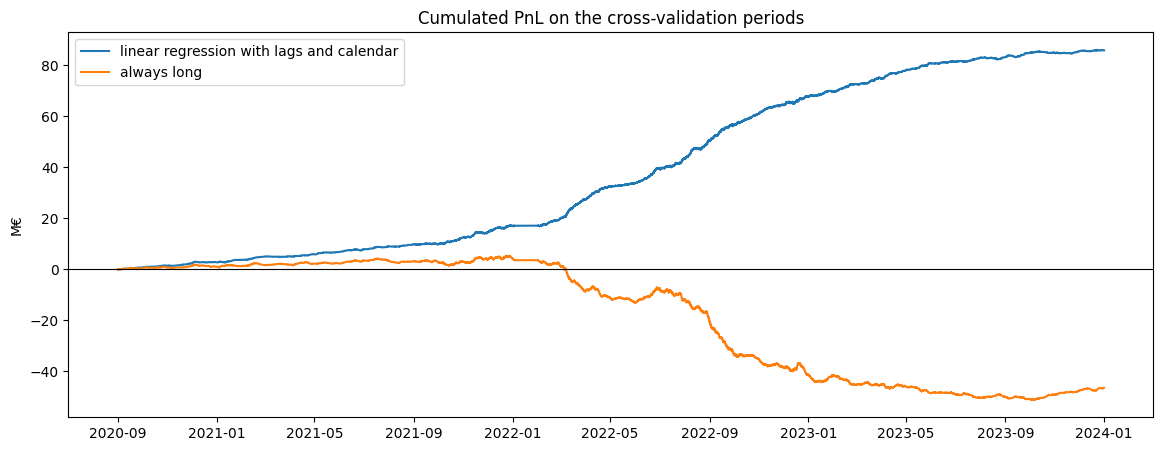

In [10]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(spread_val.index, pnl_model.cumsum() / 1e6, label="linear regression with lags and calendar")
ax.plot(spread_val.index, pnl_always_long.cumsum() / 1e6, label="always long")
ax.axhline(0, color="black", linewidth=0.8)
ax.set_title("Cumulated PnL on the cross-validation periods")
ax.set_ylabel("M€")
ax.legend()
plt.show()

**Takeaways**
- *Always long* loses money: the spread is positive about half of the time, there is no bias to exploit.
- A simple linear regression captures about 15% of the maximum achievable PnL, using only information available the day before.
- The result stays far from perfect foresight: the spread also depends on real-time events (forecast errors, plant outages) that day-ahead forecasts cannot see.

## 6. Submission

In [11]:
model = LinearRegression()
model.fit(features_train[~corrupt], y_train[~corrupt])
forecast = model.predict(features_test)

pred = pd.DataFrame({"ID": test["ID"].values, "forecast": forecast})
pred.to_csv("submission.csv", index=False)
print("File submission.csv created")
pred.head()

File submission.csv created


,ID,forecast
0,0,-24.587259
1,1,-13.898532
2,2,-14.183833
3,3,-18.423821
4,4,-21.246374
